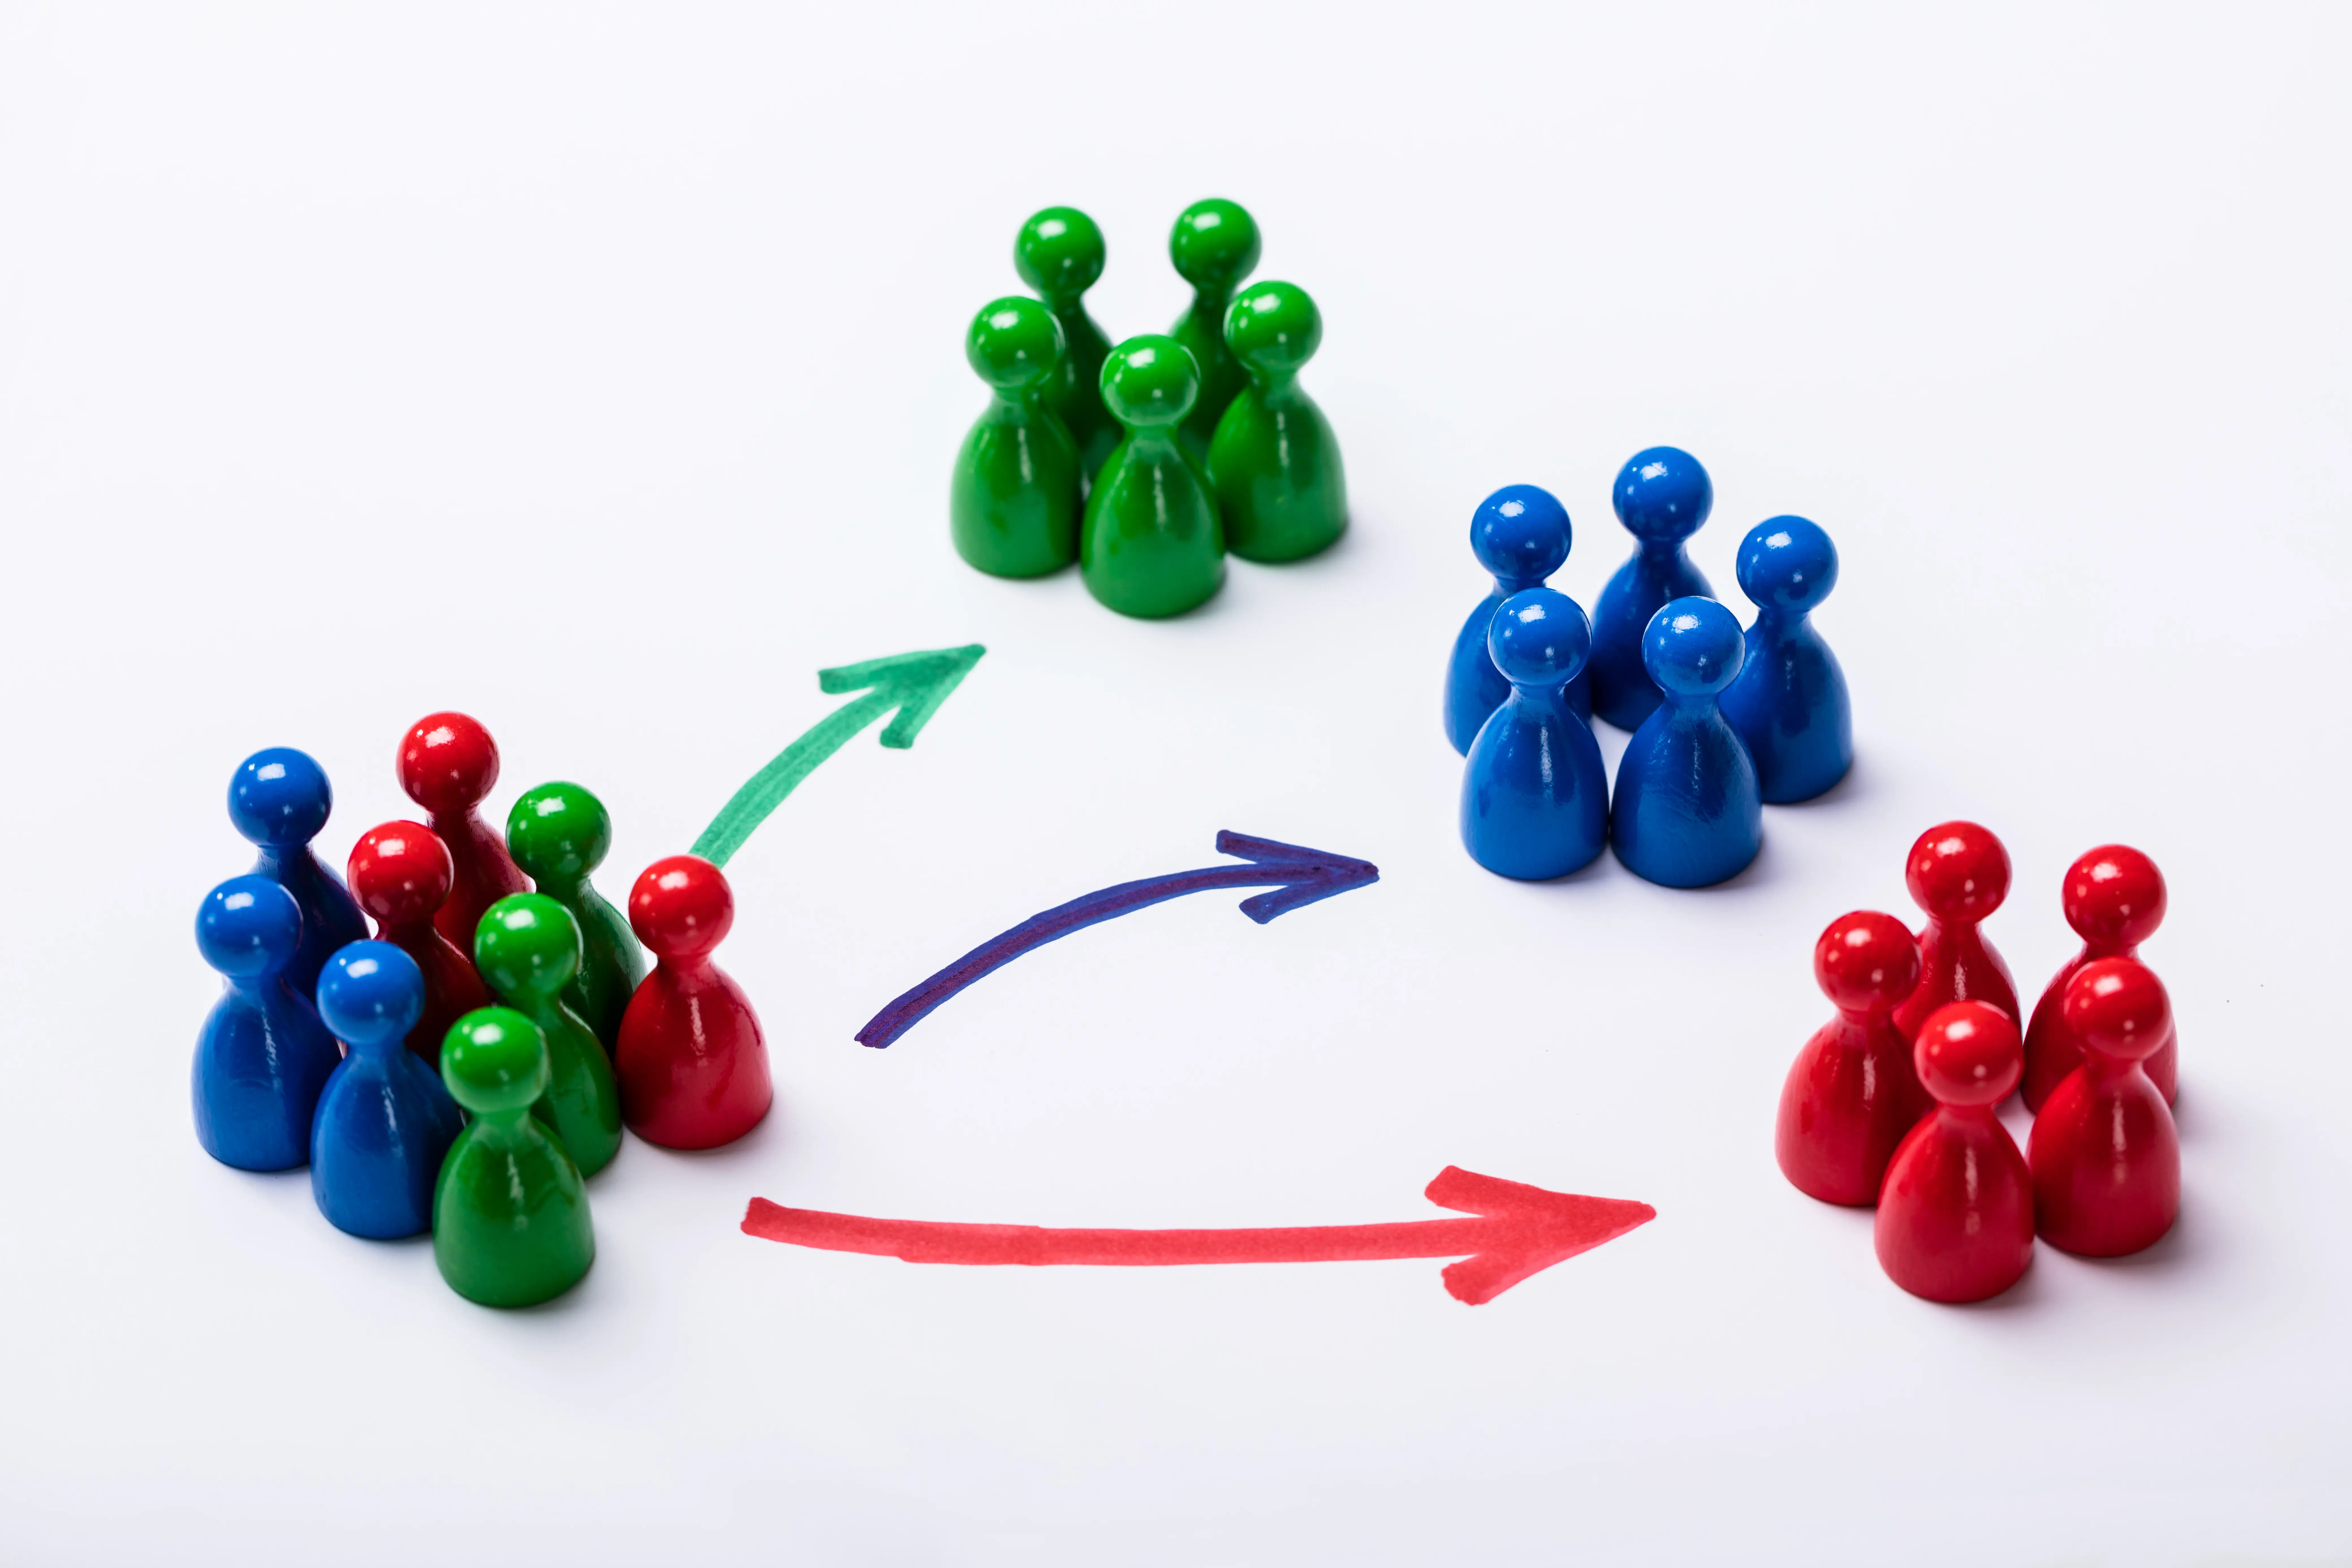

##Customer Segmentation & Campaign Analysis

**Objective**

The goal of this project is to segment customers based on their behavior and analyze campaign response to identify high-value target customers.

**Dataset Description**

The dataset contains customer demographics, income, spending behavior, and campaign response data.

**Steps Performed**

1. Data Cleaning
2. Feature Engineering
3. Outlier Handling
4. Feature Scaling
5. KMeans Clustering
6. Cluster Analysis

In [ ]:
#Loading libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset in Python

In [ ]:
df= pd.read_csv("/content/marketing_campaign.csv", sep="\t")

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Check Data Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

#Data Cleaning

Data Type Fixes

In [ ]:
# Convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

Check Missing Values and duplicate values

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.isnull().sum().sum()

np.int64(24)

In [ ]:
df['Income'].fillna(df['Income'].median(), inplace=True)
#I filled missing Income values with the median because it is robust to outliers and preserves data for analysis.

/tmp/ipykernel_6631/3650829521.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

Clean Column Names

In [ ]:
df.columns = df.columns.str.strip() # remove extra spaces
#Cleaned column names for consistency and easier handling.

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

#Feature Engineering

Create Important Features (Feature Engineering)

In [ ]:
#Age Column
df['Age'] = 2024 - df['Year_Birth']
#I derived Age from Year_Birth to analyze customer demographics and segment them effectively.

In [ ]:
#Total Spending
df['Total_Spending'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)
#Created Total_Spending to understand overall customer value across products.

In [ ]:
#Total Campaigns Accepted
df['Total_Accepted'] = (
     df['AcceptedCmp1'] + df['AcceptedCmp2'] +
     df['AcceptedCmp3'] + df['AcceptedCmp4'] +
     df['AcceptedCmp5']
)
#Calculated total accepted campaigns to analyze customer engagement.

In [ ]:
#Total Children i.e Combine Kidhome + Teenhome
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
#Created Total_Children to analyze family composition, which can affect spending and campaign targeting.

In [ ]:
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,Total_Accepted,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,3,11,1,67,1617,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,3,11,0,70,27,0,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,3,11,0,59,776,0,0


Quick Stats Check

In [ ]:
df[['Age', 'Income', 'Total_Spending', 'Total_Accepted']].describe().T
#I explored basic statistics to detect anomalies and understand customer behavior ranges.

,count,mean,std,min,25%,50%,75%,max
Age,2240.0,55.194196,11.984069,28.0,47.00,54.0,65.00,131.0
Income,2240.0,52237.975446,25037.955891,1730.0,35538.75,51381.5,68289.75,666666.0
Total_Spending,2240.0,605.798214,602.249288,5.0,68.75,396.0,1045.50,2525.0
Total_Accepted,2240.0,0.297768,0.678381,0.0,0.00,0.0,0.00,4.0


Handle Outliers

In [ ]:
#Income too high or 0 #Cleaning
df = df[df['Income']>0]
#Removed unrealistic income values to improve model accuracy

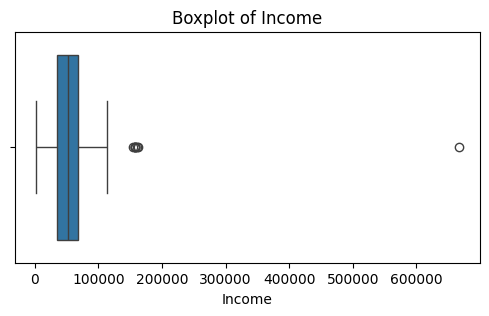

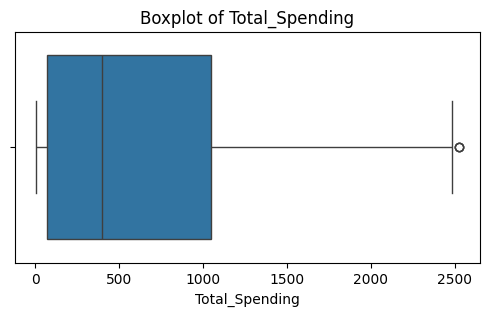

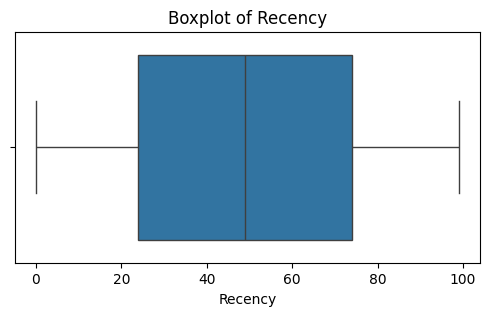

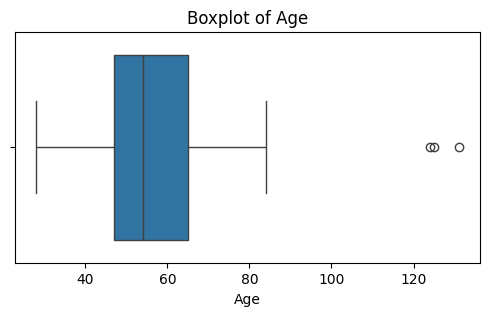

In [ ]:
#check outliers and tell me which col we have outliers #Visualization

cols = ['Income','Total_Spending','Recency','Age']
for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
#outlier handling
for col in cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].apply(lambda x: upper if x > upper else (lower if x < lower else x))

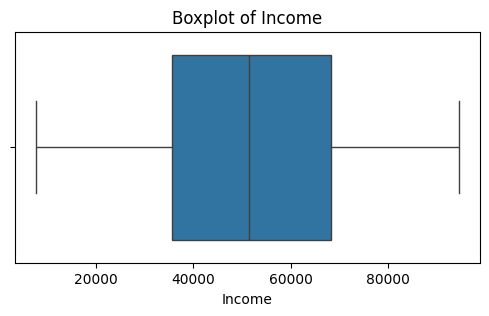

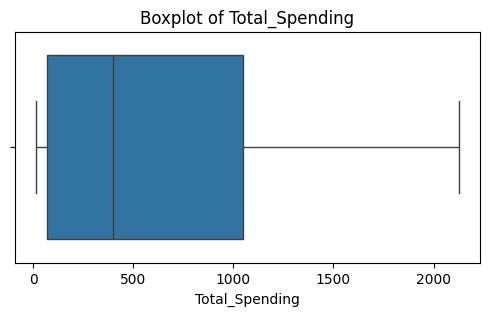

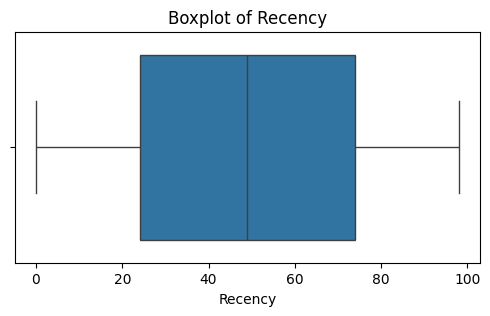

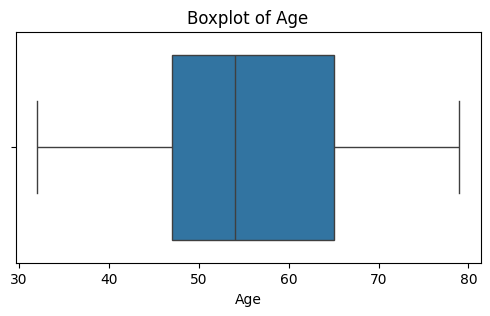

In [ ]:
cols = ['Income','Total_Spending','Recency','Age']
for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

KMeans Clustering

In [ ]:
#Select Features for Clustering
features = ['Age', 'Income', 'Total_Spending', 'Recency', 'Total_Accepted']
X=df[features]
#I selected Age, Income, Total Spending, Recency, and Total Campaigns Accepted
#because these best to capture customer demographics, value, and engagement.

In [ ]:
#Scale Features
#KMeans is distance-based, so scaling is important:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)

#I standardized features to ensure all variables contribute equally to clustering,
#avoiding bias from large numeric ranges like Income or Total Spending.

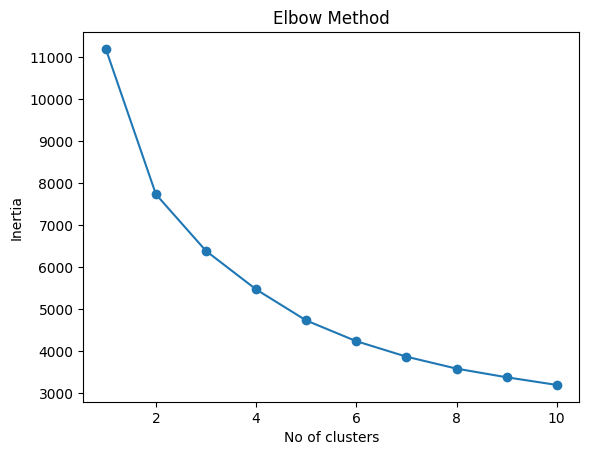

In [ ]:
#Find Optimal Number of Clusters (Elbow Method)

from sklearn.cluster import KMeans

inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state=42)
    kmeans.fit(X_Scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker ='o')
plt.xlabel('No of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

#“I used the Elbow Method to determine the optimal number of clusters by identifying the point
#where adding more clusters no longer significantly reduces inertia.”

In [ ]:
#Fit KMeans and Create Cluster Column
# Suppose elbow suggests 3 clusters
kmeans = KMeans(n_clusters = 3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_Scaled)

#I applied KMeans with 3 clusters, labeling each customer based on their segment.

In [ ]:
#Analyze Clusters
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)
#Cluster analysis helped identify high, medium, and low-value customer segments, which guides targeted marketing strategies.

               Age        Income  Total_Spending    Recency  Total_Accepted
Cluster                                                                    
0        51.534467  34879.438818      137.828111  48.340197        0.086840
1        59.972318  65710.740046      925.054210  50.274510        0.128028
2        54.437500  78230.367266     1551.316406  48.453125        1.792969


Helps understand cluster characteristics:

Cluster 0 → high spenders

Cluster 1 → medium value

Cluster 2 → low spenders

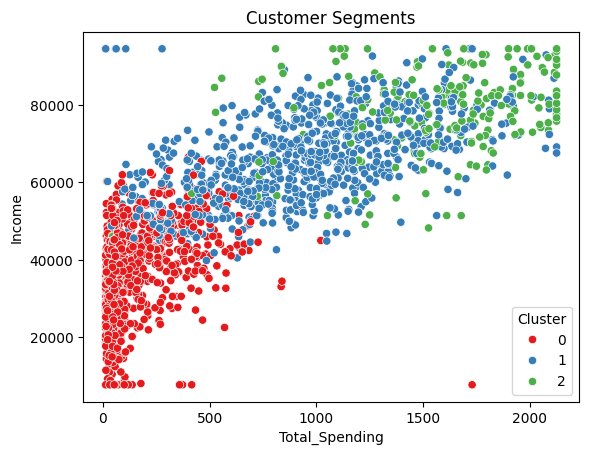

In [ ]:
#Visualize Clusters
sns.scatterplot(data = df, x = 'Total_Spending', y = 'Income', hue = 'Cluster', palette = 'Set1')
plt.title('Customer Segments')
plt.show()

Easy to show cluster separation visually

Good for dashboards

## Key Insights

- High-income customers tend to have higher spending and respond better to campaigns
- Low-value customers show lower engagement
- Customer segmentation helps in targeted marketing strategies

## Business Recommendations

- Target high-value customers with premium offers
- Provide discounts to medium-value customers to increase engagement
- Re-engage low-value customers with personalized campaigns

In [40]:
#to save the final dataset
df.to_csv("customer_segmentation.csv", index=False)

In [41]:
from google.colab import files
files.download("customer_segmentation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
df['Age'] = df['Age'].astype(int)
df['Recency'] = df['Recency'].astype(int)
df['Total_Accepted'] = df['Total_Accepted'].astype(int)
df['Total_Children'] = df['Total_Children'].astype(int)

In [43]:
#to save the final dataset
df.to_csv("customer_segmentation.csv", index=False)

In [44]:
from google.colab import files
files.download("customer_segmentation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>